In [6]:
class Option:
    def __init__(self, option_type, strike, spot, premium):
        if option_type not in ['call', 'put']:
            raise ValueError("option_type must be 'call' or 'put'")
        self.option_type = option_type
        self.strike = strike
        self.spot = spot
        self.premium = premium
    
    def payoff_at_expiry(self, future_spot):
        if self.option_type == 'call':
            intrinsic = max(0, future_spot - self.strike)
        elif self.option_type == 'put':
            intrinsic = max(0, self.strike - future_spot)
        return intrinsic - self.premium
    
    def seller_payoff(self, future_spot):
        return -self.payoff_at_expiry(future_spot)

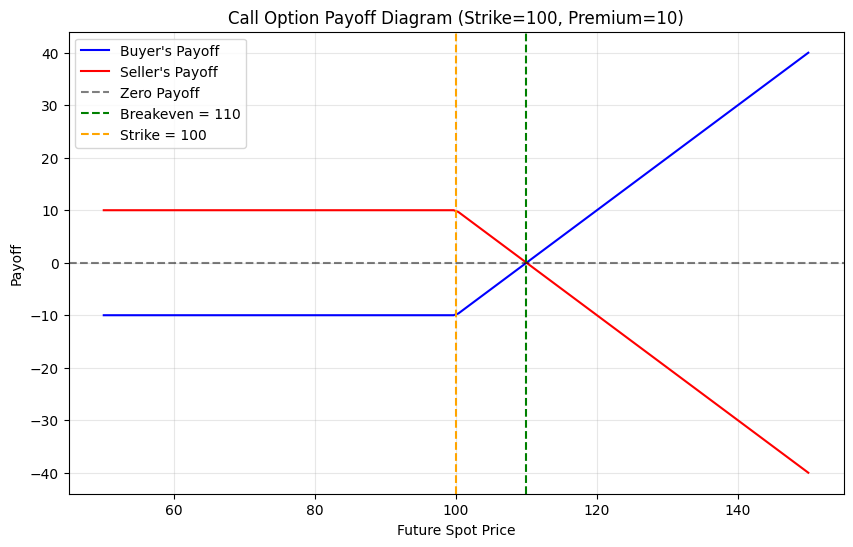

In [ ]:
# Task 2: Plot payoff diagrams
import matplotlib.pyplot as plt
import numpy as np

# Create a call option with strike=100, premium=10
call_option = Option('call', strike=100, spot=100, premium=10)

# Generate range of future spot prices from 50 to 150
future_spots = np.linspace(50, 150, 100)

# Calculate payoffs for buyer and seller
buyer_payoffs = [call_option.payoff_at_expiry(s) for s in future_spots]
seller_payoffs = [call_option.seller_payoff(s) for s in future_spots]

# Calculate breakeven point for call option
breakeven = call_option.strike + call_option.premium

# Plot
plt.figure(figsize=(10, 6))
plt.plot(future_spots, buyer_payoffs, label="Buyer's Payoff", color='blue')
plt.plot(future_spots, seller_payoffs, label="Seller's Payoff", color='red')
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Zero Payoff')
plt.axvline(breakeven, color='green', linestyle='--', label=f'Breakeven = {breakeven}')
plt.axvline(call_option.strike, color='orange', linestyle='--', label=f'Strike = {call_option.strike}')

plt.title('Call Option Payoff Diagram (Strike=100, Premium=10)')
plt.xlabel('Future Spot Price')
plt.ylabel('Payoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

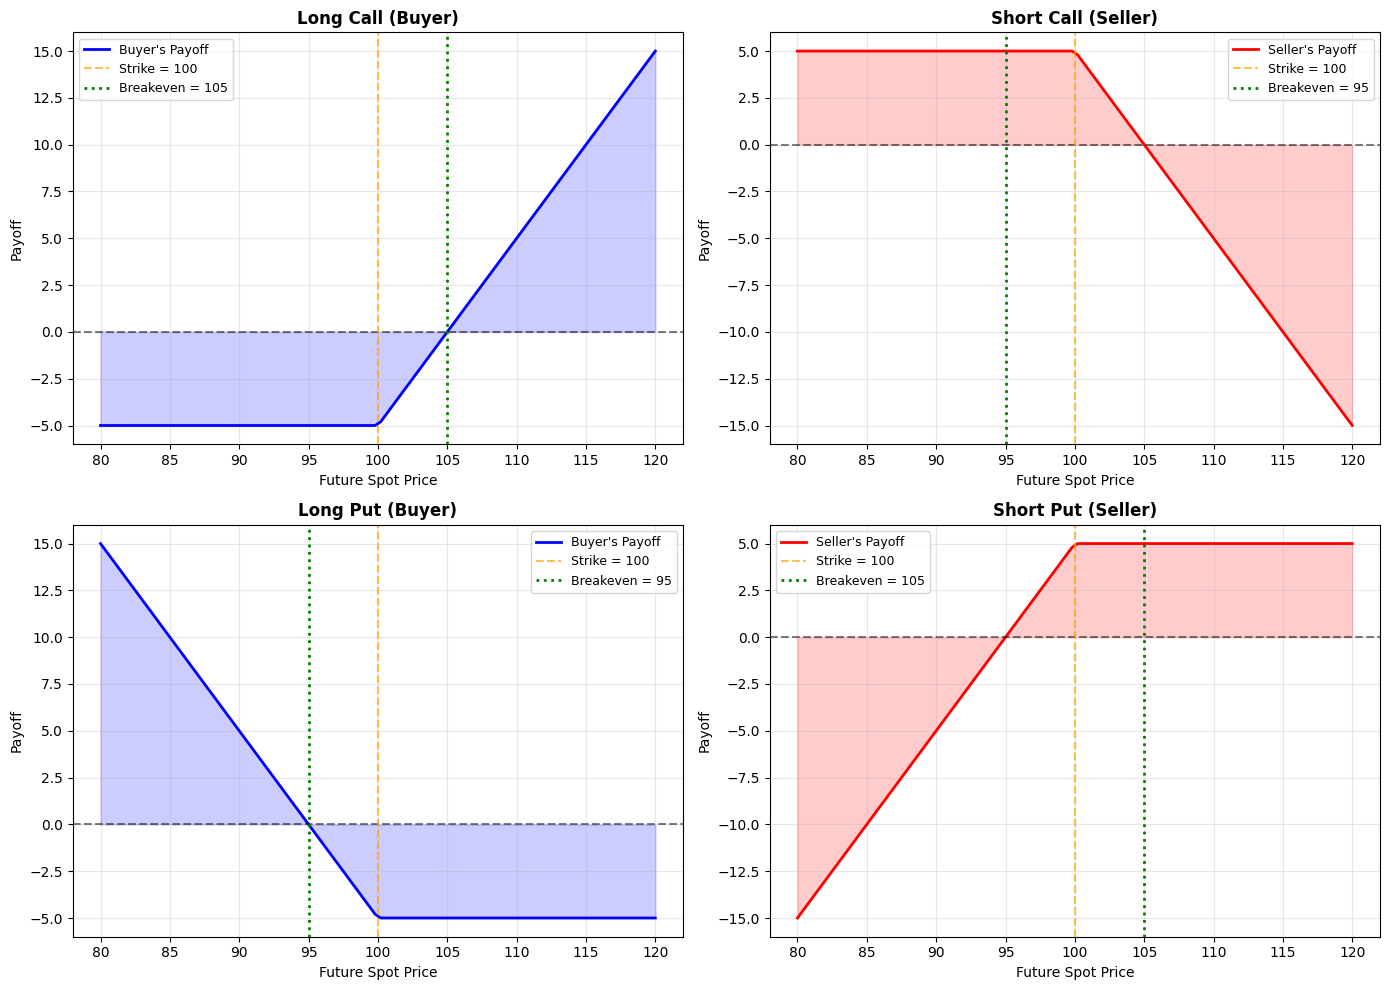


--- Experiment: Varying Strike and Premium ---



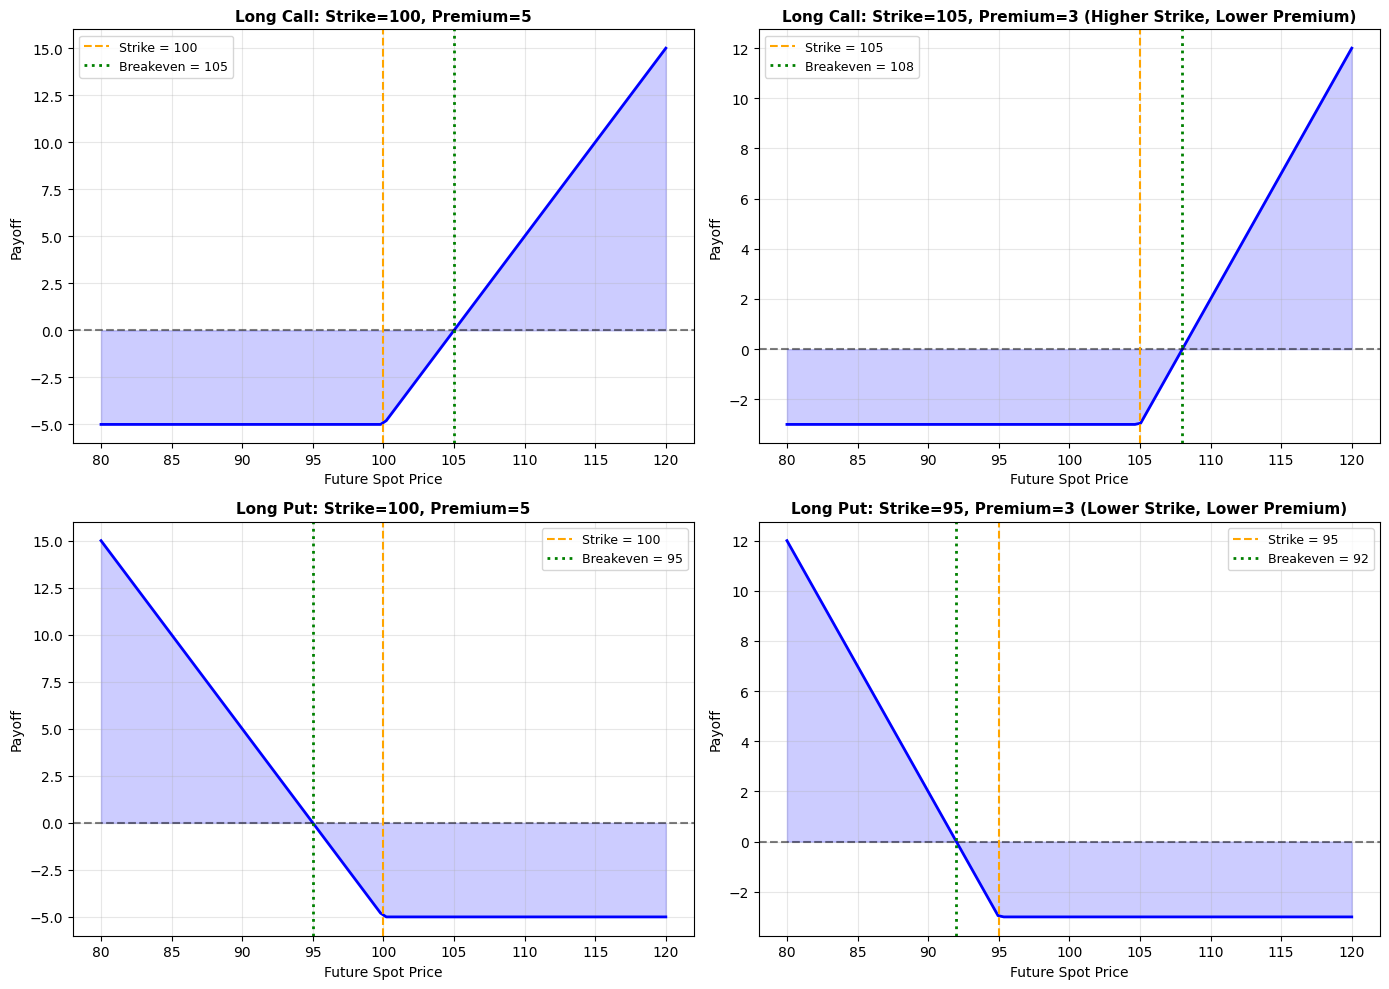

In [13]:
# Task 3: Experiment with different options
# Create separate plots for long call, short call, long put, short put
# with varying strike and premium

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Define different option scenarios
scenarios = [
    {
        'title': 'Long Call (Buyer)',
        'option': Option('call', strike=100, spot=100, premium=5),
        'ax': axes[0, 0],
        'buyer': True
    },
    {
        'title': 'Short Call (Seller)',
        'option': Option('call', strike=100, spot=100, premium=5),
        'ax': axes[0, 1],
        'buyer': False
    },
    {
        'title': 'Long Put (Buyer)',
        'option': Option('put', strike=100, spot=100, premium=5),
        'ax': axes[1, 0],
        'buyer': True
    },
    {
        'title': 'Short Put (Seller)',
        'option': Option('put', strike=100, spot=100, premium=5),
        'ax': axes[1, 1],
        'buyer': False
    }
]

# Generate range of future spot prices
future_spots = np.linspace(80, 120, 100)

# Plot each scenario
for scenario in scenarios:
    opt = scenario['option']
    ax = scenario['ax']
    
    if scenario['buyer']:
        payoffs = [opt.payoff_at_expiry(s) for s in future_spots]
        color = 'blue'
        label = "Buyer's Payoff"
    else:
        payoffs = [opt.seller_payoff(s) for s in future_spots]
        color = 'red'
        label = "Seller's Payoff"
    
    ax.plot(future_spots, payoffs, linewidth=2, color=color, label=label)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(opt.strike, color='orange', linestyle='--', alpha=0.7, label=f'Strike = {opt.strike}')
    ax.fill_between(future_spots, payoffs, 0, alpha=0.2, color=color)
    
    # Mark breakeven
    if opt.option_type == 'call':
        if scenario['buyer']:
            breakeven = opt.strike + opt.premium
        else:
            breakeven = opt.strike - opt.premium
    else:  # put
        if scenario['buyer']:
            breakeven = opt.strike - opt.premium
        else:
            breakeven = opt.strike + opt.premium
    
    ax.axvline(breakeven, color='green', linestyle=':', linewidth=2, label=f'Breakeven = {breakeven}')
    
    ax.set_title(scenario['title'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Future Spot Price')
    ax.set_ylabel('Payoff')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Experiment with different parameters
print("\n--- Experiment: Varying Strike and Premium ---\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Different parameter combinations
experiments = [
    {
        'title': 'Long Call: Strike=100, Premium=5',
        'option': Option('call', strike=100, spot=100, premium=5),
        'ax': axes[0, 0]
    },
    {
        'title': 'Long Call: Strike=105, Premium=3 (Higher Strike, Lower Premium)',
        'option': Option('call', strike=105, spot=100, premium=3),
        'ax': axes[0, 1]
    },
    {
        'title': 'Long Put: Strike=100, Premium=5',
        'option': Option('put', strike=100, spot=100, premium=5),
        'ax': axes[1, 0]
    },
    {
        'title': 'Long Put: Strike=95, Premium=3 (Lower Strike, Lower Premium)',
        'option': Option('put', strike=95, spot=100, premium=3),
        'ax': axes[1, 1]
    }
]

future_spots = np.linspace(80, 120, 100)

for exp in experiments:
    opt = exp['option']
    ax = exp['ax']
    
    payoffs = [opt.payoff_at_expiry(s) for s in future_spots]
    ax.plot(future_spots, payoffs, linewidth=2, color='blue')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.axvline(opt.strike, color='orange', linestyle='--', label=f'Strike = {opt.strike}')
    ax.fill_between(future_spots, payoffs, 0, alpha=0.2, color='blue')
    
    # Mark breakeven
    if opt.option_type == 'call':
        breakeven = opt.strike + opt.premium
    else:
        breakeven = opt.strike - opt.premium
    
    ax.axvline(breakeven, color='green', linestyle=':', linewidth=2, label=f'Breakeven = {breakeven}')
    
    ax.set_title(exp['title'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Future Spot Price')
    ax.set_ylabel('Payoff')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Question 1: "If I sell a put option, where does my potential profit come from? What risks do I face?"
Your answer: "My maximum profit is the premium paid by the put option buyer, and loss can be unlimited."

This is partially correct but needs two important fixes:

Profit source is correct – You keep the premium if the option expires worthless (if spot price stays above strike).

Loss is NOT unlimited – For a put seller, the loss is limited because the stock price can't go below zero. The maximum loss = Strike Price - Premium Received. (For a call seller, loss can be unlimited because stock price can rise indefinitely.)

Improved answer:

"When I sell a put option, my potential profit comes from the premium the buyer pays me. I keep this entire premium if the option expires worthless (i.e., if the stock price stays above the strike price at expiry). The risk I face is that the stock price falls below the strike. My loss is limited because the stock can only drop to zero. The maximum loss is calculated as: (Strike Price – Premium Received). So unlike a short call, a short put has limited risk."

Question 2: "If I buy a call option, what market condition am I betting on? Why might someone sell it to me?"
Your answer: "If I buy a call option, I am expecting a positive move in market or increase in spot price. Someone might be thinking opposite so he might want to sell."

This is conceptually correct but could be more precise:

Market condition – You're betting on the price rising above the strike price plus the premium you paid (the breakeven point).

Why someone sells – The seller has the opposite view (expects price to stay below the breakeven) OR wants to collect premium income as a strategy (e.g., covered call).

Improved answer:

"When I buy a call option, I am betting that the spot price will rise significantly—specifically, above the strike price plus the premium I paid (the breakeven point). The more it rises above that, the more I profit.

Someone might sell me that call option because they have the opposite expectation (they believe the price will stay below the breakeven). Alternatively, they might be using a strategy like a covered call, where they already own the stock and sell calls to generate income, accepting that they might have to sell their shares if the price rises sharply."